# Digit Recognition with scikit-learn (`load_digits`)

The dataset contains 1,797 handwritten digit images (0-9), each 8x8 pixels.

In [11]:
# Load the data (built into scikit-learn, downloads nothing, no files needed)
from sklearn.datasets import load_digits

digits = load_digits()
X, y = digits.data, digits.target  # X: flattened 8x8 images (64 features), y: digit labels 0-9

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", set(y))

X shape: (1797, 64)
y shape: (1797,)
Classes: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)}


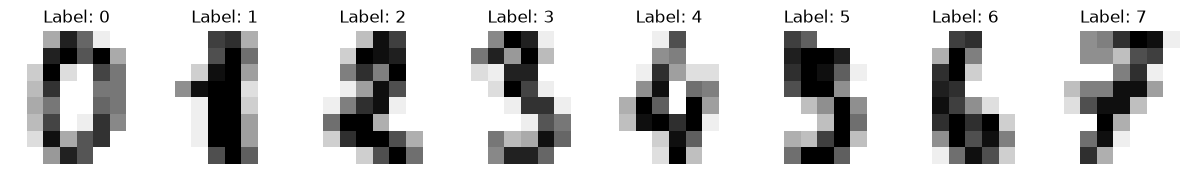

In [12]:
# Preview a few sample digits
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 8, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap="gray_r")
    ax.set_title(f"Label: {digits.target[i]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [13]:
# Split into training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 1437
Test samples: 360


In [14]:
# Train a Support Vector Machine classifier
from sklearn.svm import SVC

model = SVC(gamma=0.001)
model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.001
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [15]:
# Evaluate on the test set
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.9888888888888889

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      0.97      0.99        34
           4       1.00      1.00      1.00        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       0.97      0.97      0.97        34
           8       1.00      1.00      1.00        30
           9       0.97      0.97      0.97        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



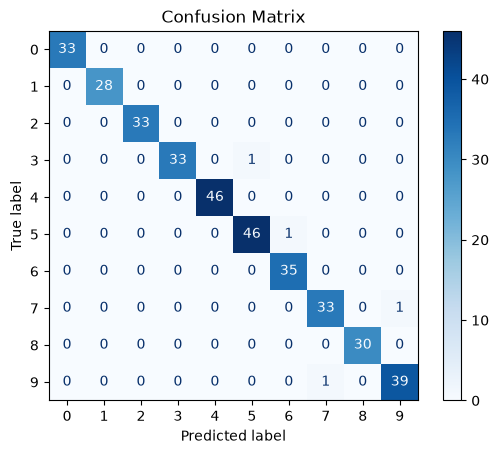

In [16]:
# Confusion matrix - see which digits get confused with each other
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

## Try it on individual test images

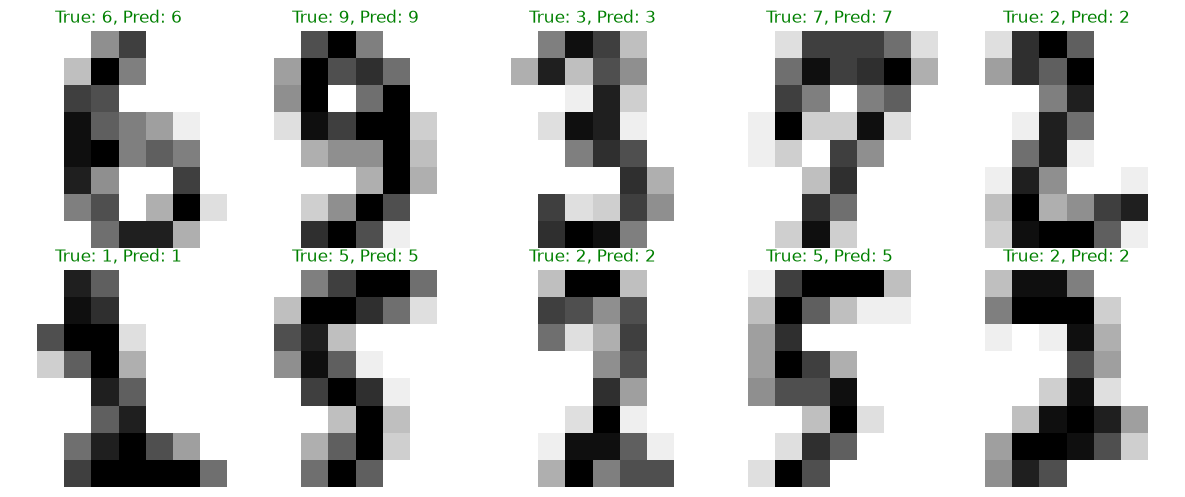

In [17]:
# Visualize some predictions vs. the true labels
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.ravel()):
    image = X_test[i].reshape(8, 8)
    true_label = y_test[i]
    pred_label = y_pred[i]
    ax.imshow(image, cmap="gray_r")
    color = "green" if true_label == pred_label else "red"
    ax.set_title(f"True: {true_label}, Pred: {pred_label}", color=color)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Comparing Different Classifiers

The SVM above worked well, but let's compare it against a few other common
classifiers to see how they perform on the same data.

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

models = {
    "SVM": SVC(gamma=0.001),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=5000),
}

results = {}
for name, clf in models.items():
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name:20s} accuracy: {acc:.4f}")

SVM                  accuracy: 0.9889
Random Forest        accuracy: 0.9722
KNN                  accuracy: 0.9861
Logistic Regression  accuracy: 0.9750


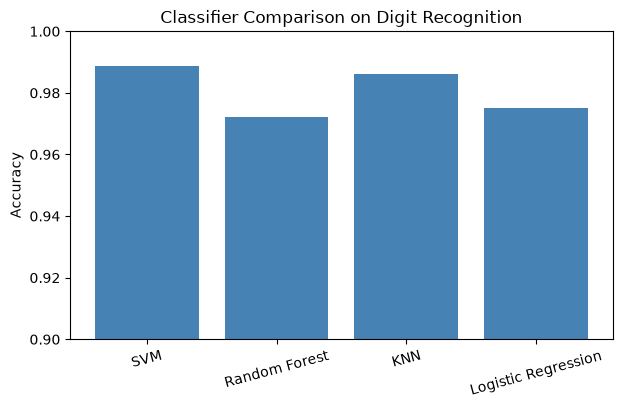

In [19]:
# Visualize the comparison as a bar chart
plt.figure(figsize=(7, 4))
plt.bar(results.keys(), results.values(), color="steelblue")
plt.ylabel("Accuracy")
plt.ylim(0.9, 1.0)
plt.title("Classifier Comparison on Digit Recognition")
plt.xticks(rotation=15)
plt.show()

## Hyperparameter Tuning with GridSearchCV

Instead of guessing the SVM's `C` and `gamma` values, `GridSearchCV` tries
several combinations automatically and picks the best one using
cross-validation.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.1, 1, 10],
    "gamma": [0.01, 0.001, 0.0001],
}

grid_search = GridSearchCV(SVC(), param_grid, cv=5)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

# Evaluate the tuned model on the test set
best_model = grid_search.best_estimator_
tuned_preds = best_model.predict(X_test)
print("Test set accuracy with tuned model:", accuracy_score(y_test, tuned_preds))